In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

DATA_DIR = Path('D:/HII/OneDrive/HydroDataSci/Project/เกณฑ์ฝน จ.สงขลา/Data')
OUTPUT_DIR = Path('D:/HII/rainfall_threshold_songkla/output')

# Data Loading

In [3]:
df = pd.read_csv(
DATA_DIR / '20260410_Rainfall-สงขลา.csv',
    encoding='utf-8-sig',
    parse_dates=['rainfall_datetime'],
    dtype={'tele_station_oldcode': str}
)

In [4]:
df_r1h = pd.read_csv(
    DATA_DIR / '20260410_Rainfall1h-สงขลา.csv',
    encoding='utf-8-sig',
    parse_dates=['rainfall_datetime'],
    dtype={'tele_station_oldcode': str}
)

In [5]:
df_meta1 = pd.read_csv(
    DATA_DIR / 'm_tele_station_20220324.csv',
    encoding='utf-8-sig',
)

In [6]:
df_meta2 = pd.read_csv(
    DATA_DIR / 'm_tele_station_20260507.csv',
    encoding='utf-8-sig',
)

# General detail

In [7]:
df.head()

,tele_station_oldcode,station_name_th,rainfall_datetime,rainfall10m,rainfall5m,rainfall30m,rainfall1h,rainfall3h,tumbon_name,amphoe_name,province_name,tmd_area_name,agency
0,48568,สงขลา,2019-02-14 13:00:00,NaN,NaN,NaN,NaN,0.0,บ่อยาง,เมืองสงขลา,สงขลา,ภาคใต้ฝั่งตะวันออก,TMD
1,48568,สงขลา,2019-02-14 16:00:00,NaN,NaN,NaN,NaN,0.0,บ่อยาง,เมืองสงขลา,สงขลา,ภาคใต้ฝั่งตะวันออก,TMD
2,48568,สงขลา,2019-02-14 19:00:00,NaN,NaN,NaN,NaN,0.0,บ่อยาง,เมืองสงขลา,สงขลา,ภาคใต้ฝั่งตะวันออก,TMD
3,48568,สงขลา,2019-02-14 22:00:00,NaN,NaN,NaN,NaN,0.0,บ่อยาง,เมืองสงขลา,สงขลา,ภาคใต้ฝั่งตะวันออก,TMD
4,48568,สงขลา,2019-02-15 01:00:00,NaN,NaN,NaN,NaN,0.0,บ่อยาง,เมืองสงขลา,สงขลา,ภาคใต้ฝั่งตะวันออก,TMD


In [8]:
df_r1h.head()

,tele_station_oldcode,station_name_th,rainfall_datetime,rainfall1h,tumbon_name,amphoe_name,province_name
0,FOP069,โรงเรียน ตชด.บ้านส้านักเอาะ,2023-02-18 09:00:00,0.2,เขาแดง,สะบ้าย้อย,สงขลา
1,FOP069,โรงเรียน ตชด.บ้านส้านักเอาะ,2023-02-18 10:00:00,0.0,เขาแดง,สะบ้าย้อย,สงขลา
2,FOP069,โรงเรียน ตชด.บ้านส้านักเอาะ,2023-02-18 11:00:00,0.0,เขาแดง,สะบ้าย้อย,สงขลา
3,FOP069,โรงเรียน ตชด.บ้านส้านักเอาะ,2023-02-18 12:00:00,0.0,เขาแดง,สะบ้าย้อย,สงขลา
4,FOP069,โรงเรียน ตชด.บ้านส้านักเอาะ,2023-02-18 13:00:00,0.0,เขาแดง,สะบ้าย้อย,สงขลา


In [9]:
df_meta1.head()

,id,subbasin_id,agency_id,geocode_id,tele_station_name_th,tele_station_name_en,tele_station_lat,tele_station_long,tele_station_oldcode,tele_station_type,...,critical_level_m,critical_level_msl,reference_id,subbasin_id_22,basin_id_22,subbasin_id_25,basin_id_25,river_gid,river_distant,adjust_geocode_id
0,1032662,106.0,12.0,1950.0,Rain เธเธธเธ•เธฐเนเธ,NaN,14.433429,101.87185,M_RAIN,A,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3538,148.0,8.0,2715.0,เธญ.เธ•เธฃเธฐเธเธฒเธฃเธเธทเธเธเธฅ,Trakan Phuet Phon,15.614920,105.01614,PMTS11,A,...,NaN,NaN,NaN,148.0,5.0,105.0,5.0,141708.0,0.007901,NaN
2,501187,234.0,3.0,6171.0,เธเนเธฒเธเธเนเธณเธเธงเธ,NaN,17.438261,100.67500,STN1149,R,...,NaN,NaN,NaN,234.0,9.0,161.0,9.0,82979.0,0.001031,NaN
3,651,209.0,9.0,6107.0,เธเธฅเธญเธเธเธฑเธเธเนเธณเธขเธก-เธเนเธฒ...,NaN,17.366200,99.84370,DIN001,A,...,NaN,NaN,NaN,209.0,8.0,147.0,8.0,84208.0,0.000043,NaN
4,1849,325.0,3.0,7313.0,เธเนเธฒเธเธชเธณเธเธฑเธเน€เธเธตเธขเธ,NaN,8.934702,99.70000,STN0066,R,...,NaN,NaN,NaN,325.0,22.0,220.0,21.0,216917.0,0.000739,NaN


In [10]:
df_meta2.head()

,tele_station_oldcode,tele_station_name,tele_station_lat,tele_station_long,tumbon_name,amphoe_name,province_name,agency_shortname,tele_station_type,tmd_area_name,basin_name,subbasin_name
0,0000,องค์การบริหารส่วนตำบลห้วยผา,19.426110,97.998340,หมอกจำแป่,เมืองแม่ฮ่องสอน,แม่ฮ่องสอน,DISASTER,R,ภาคเหนือ,สาละวิน,น้ำแม่ปายตอนล่างส่วนที่ 2
1,48300,แม่ฮ่องสอน,19.298972,97.975778,จองคำ,เมืองแม่ฮ่องสอน,แม่ฮ่องสอน,TMD,R,ภาคเหนือ,สาละวิน,น้ำแม่ปายตอนล่างส่วนที่ 2
2,48302,ดอยอ่างขาง,19.931389,99.048333,ม่อนปิ่น,ฝาง,เชียงใหม่,TMD,R,ภาคเหนือ,โขงเหนือ,น้ำแม่ฝาง
3,48303,เชียงราย,19.961389,99.881389,บ้านดู่,เมืองเชียงราย,เชียงราย,TMD,R,ภาคเหนือ,โขงเหนือ,น้ำแม่กกตอนล่างส่วนที่ 3
4,48304,เชียงราย สกษ.,19.870833,99.782778,ป่าอ้อดอนชัย,เมืองเชียงราย,เชียงราย,TMD,R,ภาคเหนือ,โขงเหนือ,น้ำแม่กกตอนล่างส่วนที่ 2


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8037169 entries, 0 to 8037168
Data columns (total 13 columns):
 #   Column                Dtype         
---  ------                -----         
 0   tele_station_oldcode  str           
 1   station_name_th       str           
 2   rainfall_datetime     datetime64[us]
 3   rainfall10m           float64       
 4   rainfall5m            float64       
 5   rainfall30m           float64       
 6   rainfall1h            float64       
 7   rainfall3h            float64       
 8   tumbon_name           str           
 9   amphoe_name           str           
 10  province_name         str           
 11  tmd_area_name         str           
 12  agency                str           
dtypes: datetime64[us](1), float64(5), str(7)
memory usage: 797.1 MB


In [12]:
df_r1h.info()

<class 'pandas.DataFrame'>
RangeIndex: 889283 entries, 0 to 889282
Data columns (total 7 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   tele_station_oldcode  889283 non-null  str           
 1   station_name_th       889283 non-null  str           
 2   rainfall_datetime     889283 non-null  datetime64[us]
 3   rainfall1h            889283 non-null  float64       
 4   tumbon_name           889283 non-null  str           
 5   amphoe_name           889283 non-null  str           
 6   province_name         889283 non-null  str           
dtypes: datetime64[us](1), float64(1), str(5)
memory usage: 47.5 MB


In [13]:
df_meta1.info()

<class 'pandas.DataFrame'>
RangeIndex: 6499 entries, 0 to 6498
Data columns (total 47 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     6499 non-null   int64  
 1   subbasin_id            6475 non-null   float64
 2   agency_id              6492 non-null   float64
 3   geocode_id             6061 non-null   float64
 4   tele_station_name_th   6027 non-null   str    
 5   tele_station_name_en   2277 non-null   str    
 6   tele_station_lat       6379 non-null   float64
 7   tele_station_long      6374 non-null   float64
 8   tele_station_oldcode   6493 non-null   str    
 9   tele_station_type      5065 non-null   str    
 10  left_bank              1316 non-null   float64
 11  right_bank             1319 non-null   float64
 12  ground_level           1211 non-null   float64
 13  water_storage_station  0 non-null      float64
 14  max_waterlevel_20y     0 non-null      float64
 15  sort_order     

In [14]:
df_meta2.info()

<class 'pandas.DataFrame'>
RangeIndex: 5722 entries, 0 to 5721
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   tele_station_oldcode  5722 non-null   str    
 1   tele_station_name     5721 non-null   str    
 2   tele_station_lat      5722 non-null   float64
 3   tele_station_long     5722 non-null   float64
 4   tumbon_name           5705 non-null   str    
 5   amphoe_name           5707 non-null   str    
 6   province_name         5710 non-null   str    
 7   agency_shortname      5722 non-null   str    
 8   tele_station_type     5721 non-null   str    
 9   tmd_area_name         5710 non-null   str    
 10  basin_name            5718 non-null   str    
 11  subbasin_name         5718 non-null   str    
dtypes: float64(2), str(10)
memory usage: 536.6 KB


# Data Cleaning 

clean 'df'

In [15]:
rain_cols = ['rainfall10m', 'rainfall5m', 'rainfall30m', 'rainfall1h', 'rainfall3h']

phantom_rows = df.loc[:, rain_cols].isna().all(axis=1)

df = df[~phantom_rows]

df

print(f'Total number of phantom rows dropped: {phantom_rows.sum()} ({round(phantom_rows.sum()/len(df) * 100, 2)}%)')
print(f'Number of stations (before): {df['tele_station_oldcode'].nunique()}')
print(f'Number of stations (after): {df['tele_station_oldcode'].nunique()}')
print(f'Share of df_cleaned: {df.shape}')

Total number of phantom rows dropped: 4620647 (135.24%)
Number of stations (before): 42
Number of stations (after): 42
Share of df_cleaned: (3416522, 13)


In [16]:
df.tail()

,tele_station_oldcode,station_name_th,rainfall_datetime,rainfall10m,rainfall5m,rainfall30m,rainfall1h,rainfall3h,tumbon_name,amphoe_name,province_name,tmd_area_name,agency
8037164,VLGE10,ชุมชนบ้านเขาพระ,2018-11-05 11:00:00,999999.0,NaN,NaN,999999.0,NaN,เขาพระ,รัตภูมิ,สงขลา,ภาคใต้ฝั่งตะวันออก,HII
8037165,VLGE10,ชุมชนบ้านเขาพระ,2018-11-05 12:00:00,999999.0,NaN,NaN,999999.0,NaN,เขาพระ,รัตภูมิ,สงขลา,ภาคใต้ฝั่งตะวันออก,HII
8037166,VLGE10,ชุมชนบ้านเขาพระ,2018-11-05 13:00:00,999999.0,NaN,NaN,999999.0,NaN,เขาพระ,รัตภูมิ,สงขลา,ภาคใต้ฝั่งตะวันออก,HII
8037167,VLGE10,ชุมชนบ้านเขาพระ,2018-11-05 14:00:00,999999.0,NaN,NaN,999999.0,NaN,เขาพระ,รัตภูมิ,สงขลา,ภาคใต้ฝั่งตะวันออก,HII
8037168,VLGE10,ชุมชนบ้านเขาพระ,2018-11-05 15:00:00,999999.0,NaN,NaN,999999.0,NaN,เขาพระ,รัตภูมิ,สงขลา,ภาคใต้ฝั่งตะวันออก,HII


In [17]:
print('--- Before dropping 999999.0 ---')
print((df[rain_cols] == 999999.0).sum())
print()

df_cleaned = df.replace(999999.0, np.nan)

print('--- After dropping 999999.0 ---')
print((df[rain_cols] == 999999.0).sum())


--- Before dropping 999999.0 ---
rainfall10m    51114
rainfall5m         0
rainfall30m        0
rainfall1h     51114
rainfall3h         0
dtype: int64

--- After dropping 999999.0 ---
rainfall10m    51114
rainfall5m         0
rainfall30m        0
rainfall1h     51114
rainfall3h         0
dtype: int64


# Number of stations

In [18]:
stn_in_df = set(df['tele_station_oldcode'])
stn_in_df_r1h = set(df_r1h['tele_station_oldcode'])
stn_intersected = stn_in_df.intersection(stn_in_df_r1h)
stn_songkla = set.union(stn_in_df, stn_in_df_r1h)     # Same as: stn_songkla = stn_in_df | stn_in_df_r1h

stn_meta1 = set(df_meta1['tele_station_oldcode'])
stn_not_in_meta1 = stn_songkla - stn_meta1
stn_in_meta1 = stn_meta1.intersection(stn_songkla)

stn_meta2 = set(df_meta2['tele_station_oldcode'])
stn_not_in_meta2 = stn_songkla - stn_meta2
stn_in_meta2 = stn_meta2.intersection(stn_songkla)


In [19]:
print(f'=== Number of stations ===\n')

print(f'• Total unique stations (df and df_r1 combined): {len(stn_songkla)}')
print(f'• Stations in df_r1h: {len(stn_in_df_r1h)}')
print(f'• Stations in df: {len(stn_in_df)}')
print(f'• Intersected stations: {len(stn_intersected)} \n')

print(f'• Songkla stations (in metadata1): {len(stn_in_meta1)}')
print(f'• Songkla stations (not in metadata1): {len(stn_not_in_meta1)} \n')

print(f'• Songkla: {len(stn_songkla)}')
print(f'• Songkla stations (in metadata2): {len(stn_in_meta2)}')
print(f'• Songkla stations (not in metadata2): {len(stn_not_in_meta2)} \n')

=== Number of stations ===

• Total unique stations (df and df_r1 combined): 134
• Stations in df_r1h: 114
• Stations in df: 42
• Intersected stations: 22 

• Songkla stations (in metadata1): 91
• Songkla stations (not in metadata1): 43 

• Songkla: 134
• Songkla stations (in metadata2): 102
• Songkla stations (not in metadata2): 32 



Some stations might not exist in both df_meta1 and df_meta2 (basically they has no lat/long). So, let's check it.

In [32]:
stn_orphans = stn_songkla - stn_meta1 - stn_meta2
print(f'Number of stations not in metadata1 and metadata2: {len(stn_orphans)}')
print(stn_orphans)

Number of stations not in metadata1 and metadata2: 1
{'TH28'}


In [21]:
df_meta1_stn_latlong = df_meta1[['tele_station_oldcode', 'tele_station_lat', 'tele_station_long']]

df_meta1_stn_latlong[
    df_meta1_stn_latlong['tele_station_lat'].isnull() &              # filter by condition #1
    df_meta1_stn_latlong['tele_station_oldcode'].isin(stn_songkla)       # chain another condition #2
]

,tele_station_oldcode,tele_station_lat,tele_station_long


In [22]:
df_meta2_stn_latlong = df_meta2[['tele_station_oldcode', 'tele_station_lat', 'tele_station_long']]

df_meta2_stn_latlong[
    df_meta2_stn_latlong['tele_station_lat'].isnull() &              # filter by condition #1
    df_meta2_stn_latlong['tele_station_oldcode'].isin(stn_songkla)       # chain another condition #2
]

,tele_station_oldcode,tele_station_lat,tele_station_long


# Monthly Completeness of telestations

### Monthly Completness (df_r1h)

  The steps are:
  1. Extract year-month from datetime
  2. Count actual records per station per month
  3. Build a complete index of all station+month combinations (so missing months show as 0, not blank)
  4. Calculate expected records per month (hours in that month)
  5. Divide actual/expected → completeness %
  6. Pivot to wide format → heatmap

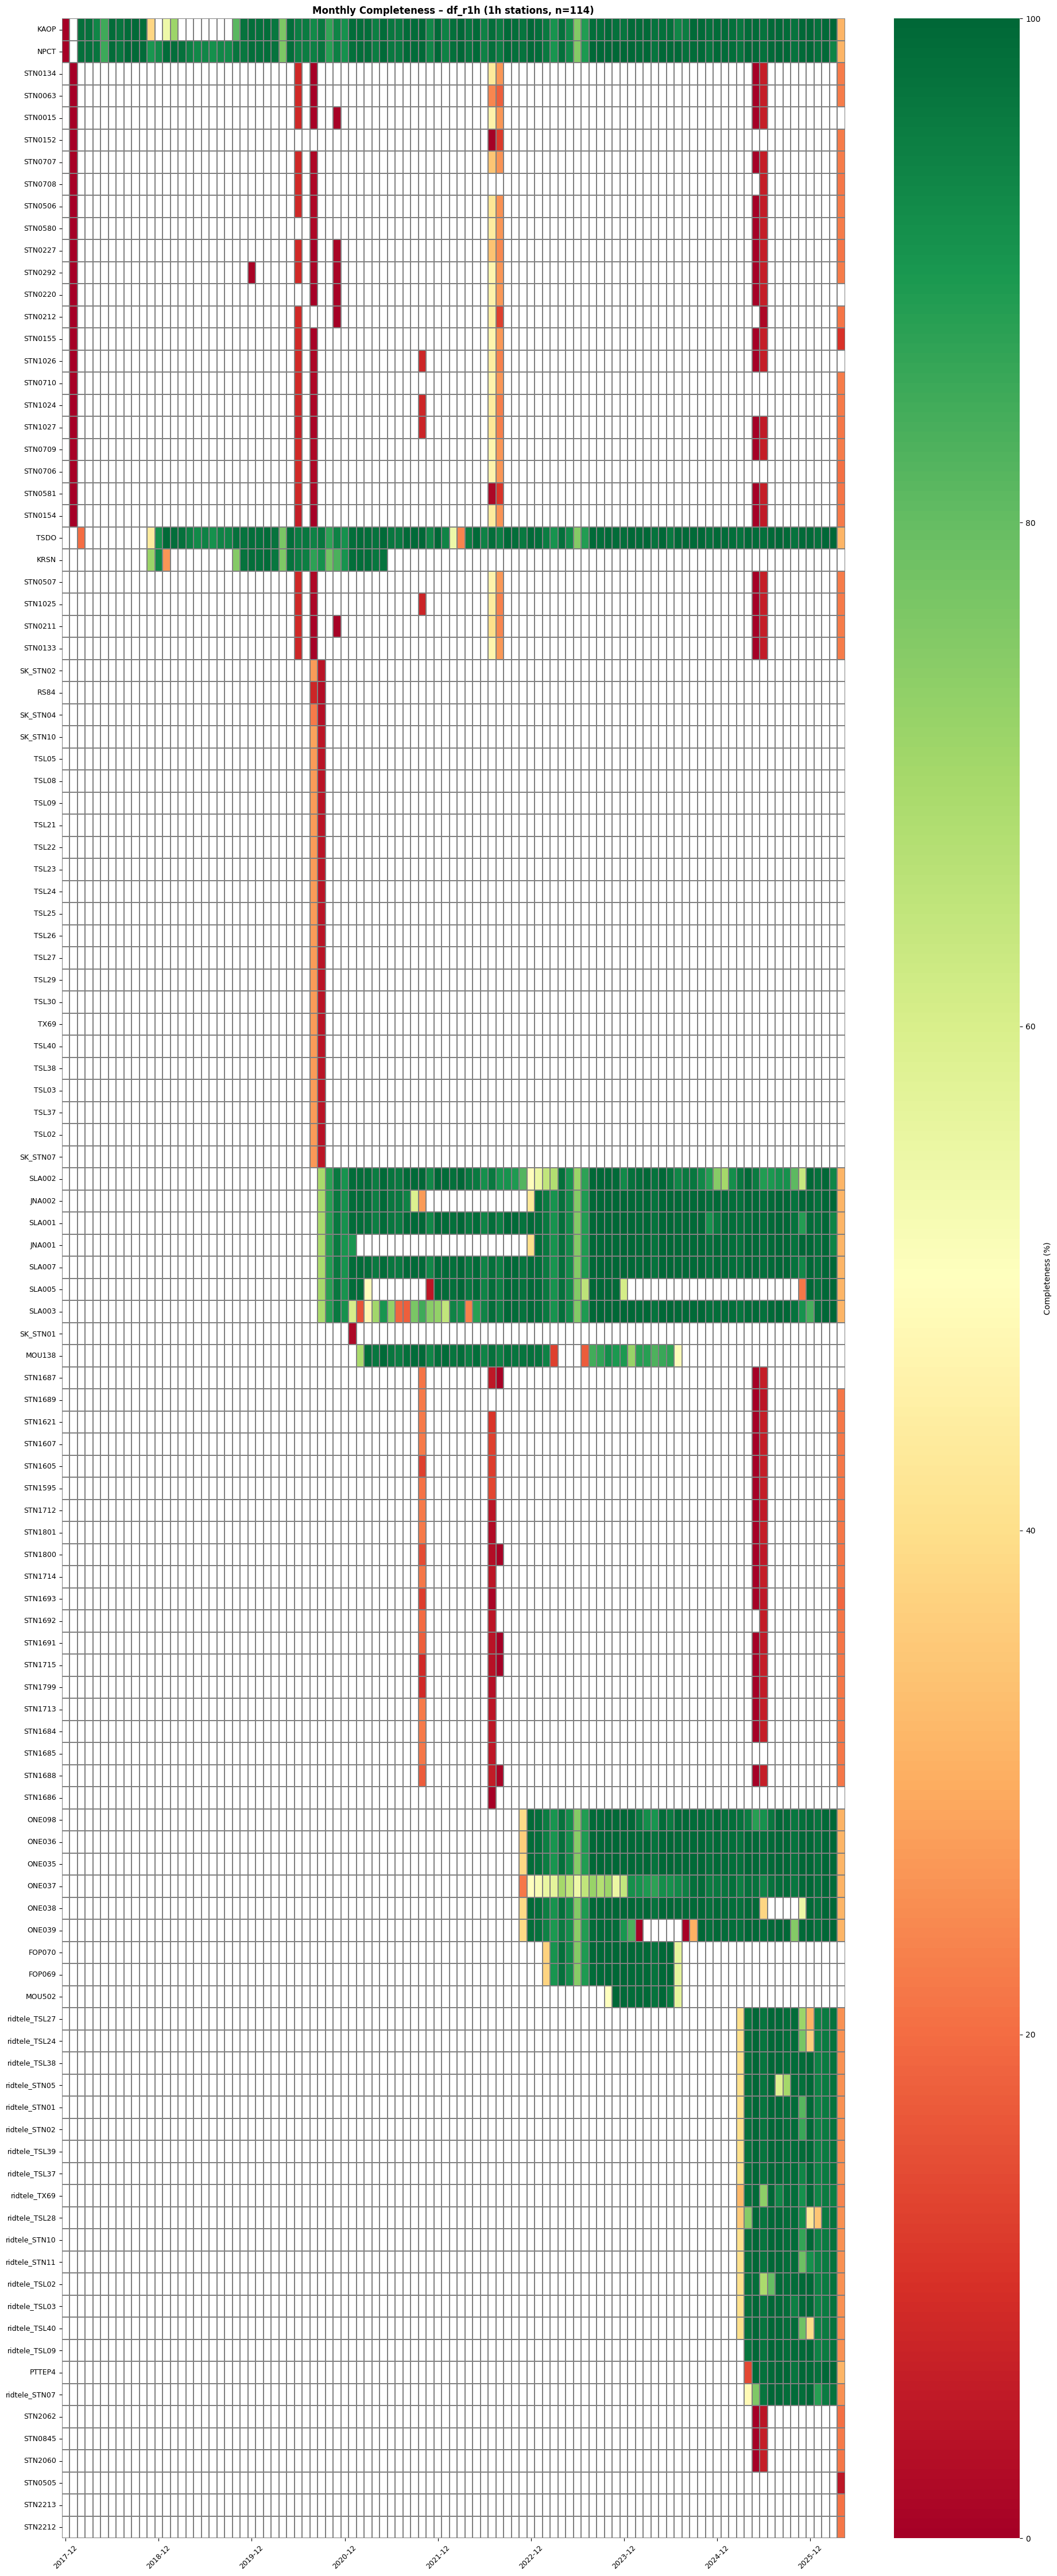

In [34]:
df_r1h['year_month'] = df_r1h['rainfall_datetime'].dt.to_period('M')
df_stn_monthly = df_r1h.groupby(['tele_station_oldcode', 'year_month']).size()

period_index = pd.period_range(
    start=df_r1h['rainfall_datetime'].min(),
    end=df_r1h['rainfall_datetime'].max(),
    freq='M'
)

full_index = pd.MultiIndex.from_product([stn_in_df_r1h, period_index], names=['station', 'year_month'])
df_stn_monthly = df_stn_monthly.reindex(full_index, fill_value=np.nan)

expected = full_index.get_level_values('year_month').days_in_month * 24
completeness = (df_stn_monthly / expected) * 100
unstacked_completeness = completeness.unstack('year_month')

first_date = unstacked_completeness.apply(lambda x: x.first_valid_index(), axis=1)
unstacked_completeness = unstacked_completeness.loc[first_date.sort_values().index]

n_stations = len(unstacked_completeness)
fig_height = max(6, n_stations * 0.5)
fig, ax = plt.subplots(figsize=(22, fig_height))
sns.heatmap(data=unstacked_completeness, ax=ax,
            cmap='RdYlGn', vmin=0, vmax=100,
            linewidths=0.3, linecolor='gray',
            cbar_kws={'label': 'Completeness (%)'},
            xticklabels=12)
ax.set_title(f'Monthly Completeness – df_r1h (1h stations, n={n_stations})',
            fontsize=12, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=9)
ax.tick_params(axis='x', labelsize=9, rotation=45)
plt.show()

In [24]:
df.isna().sum()

tele_station_oldcode          0
station_name_th               0
rainfall_datetime             0
rainfall10m              305127
rainfall5m              3416522
rainfall30m             3416522
rainfall1h               266752
rainfall3h              3149774
tumbon_name                   0
amphoe_name                   0
province_name                 0
tmd_area_name                 0
agency                        0
dtype: int64

do all stations fall cleanly into exactly one group

In [25]:
df_grouped_resolution = df.groupby('tele_station_oldcode')[['rainfall10m', 'rainfall5m', 'rainfall30m', 'rainfall1h', 'rainfall3h']].count()
df_grouped_resolution

,rainfall10m,rainfall5m,rainfall30m,rainfall1h,rainfall3h
tele_station_oldcode,,,,,
48568,0,0,0,0,17616
48569,0,0,0,0,17628
48571,0,0,0,0,17565
48574,0,0,0,0,17580
568501,0,0,0,0,3263
568502,0,0,0,0,3257
9999911,0,0,0,0,3220
EL06,0,0,0,0,14276
EL07,0,0,0,0,19925


Some station has values more than 1 resolutions.

For example 'FOP069' station has rainfall values in 'rainfall10m' and 'rainfall1h' columns.

However, it actually is a 1h-resolution station after inspecting its 'rainfall_datetime' column.

## Monthly Completness (df)

### Determine resolution of stations in df

In [26]:
df['interval'] = df.groupby('tele_station_oldcode')['rainfall_datetime'].diff().dt.total_seconds() / 60

interval_count = df.groupby(['tele_station_oldcode', 'interval']).size()

df_resolution = interval_count.groupby(level=0).idxmax().str[1].to_frame(name='interval')

total_count = interval_count.groupby('tele_station_oldcode').sum()

df_resolution['dominant_pct'] = round((interval_count.groupby(level=0).max() / total_count) * 100, 2)

df_resolution.index.name = 'station'

df_resolution

,interval,dominant_pct
station,,
48568,180.0,87.81
48569,180.0,87.90
48571,180.0,87.72
48574,180.0,87.78
568501,180.0,89.09
568502,180.0,88.88
9999911,180.0,88.10
EL06,60.0,89.30
EL07,60.0,94.22


In [27]:
df_resolution['dominant_pct'].min()

np.float64(45.86)

In [28]:
df_resolution.sort_values(by=['dominant_pct'], ascending=False, inplace=True)
display(df_resolution)

,interval,dominant_pct
station,,
ONE038,10.0,99.50
ONE036,10.0,99.43
PTTEP4,10.0,99.43
ONE035,10.0,99.39
SLA005,10.0,99.20
ONE039,10.0,98.98
SLA001,10.0,98.40
SLA007,10.0,97.83
JNA001,10.0,96.98


In [29]:
df_resolution_filtered = df_resolution[df_resolution['dominant_pct'] >= 70]
df_stn_great = df_resolution_filtered.index.tolist()

Only 2 stations were dropped (40 stations pass the 70% dominant_pct threshold)

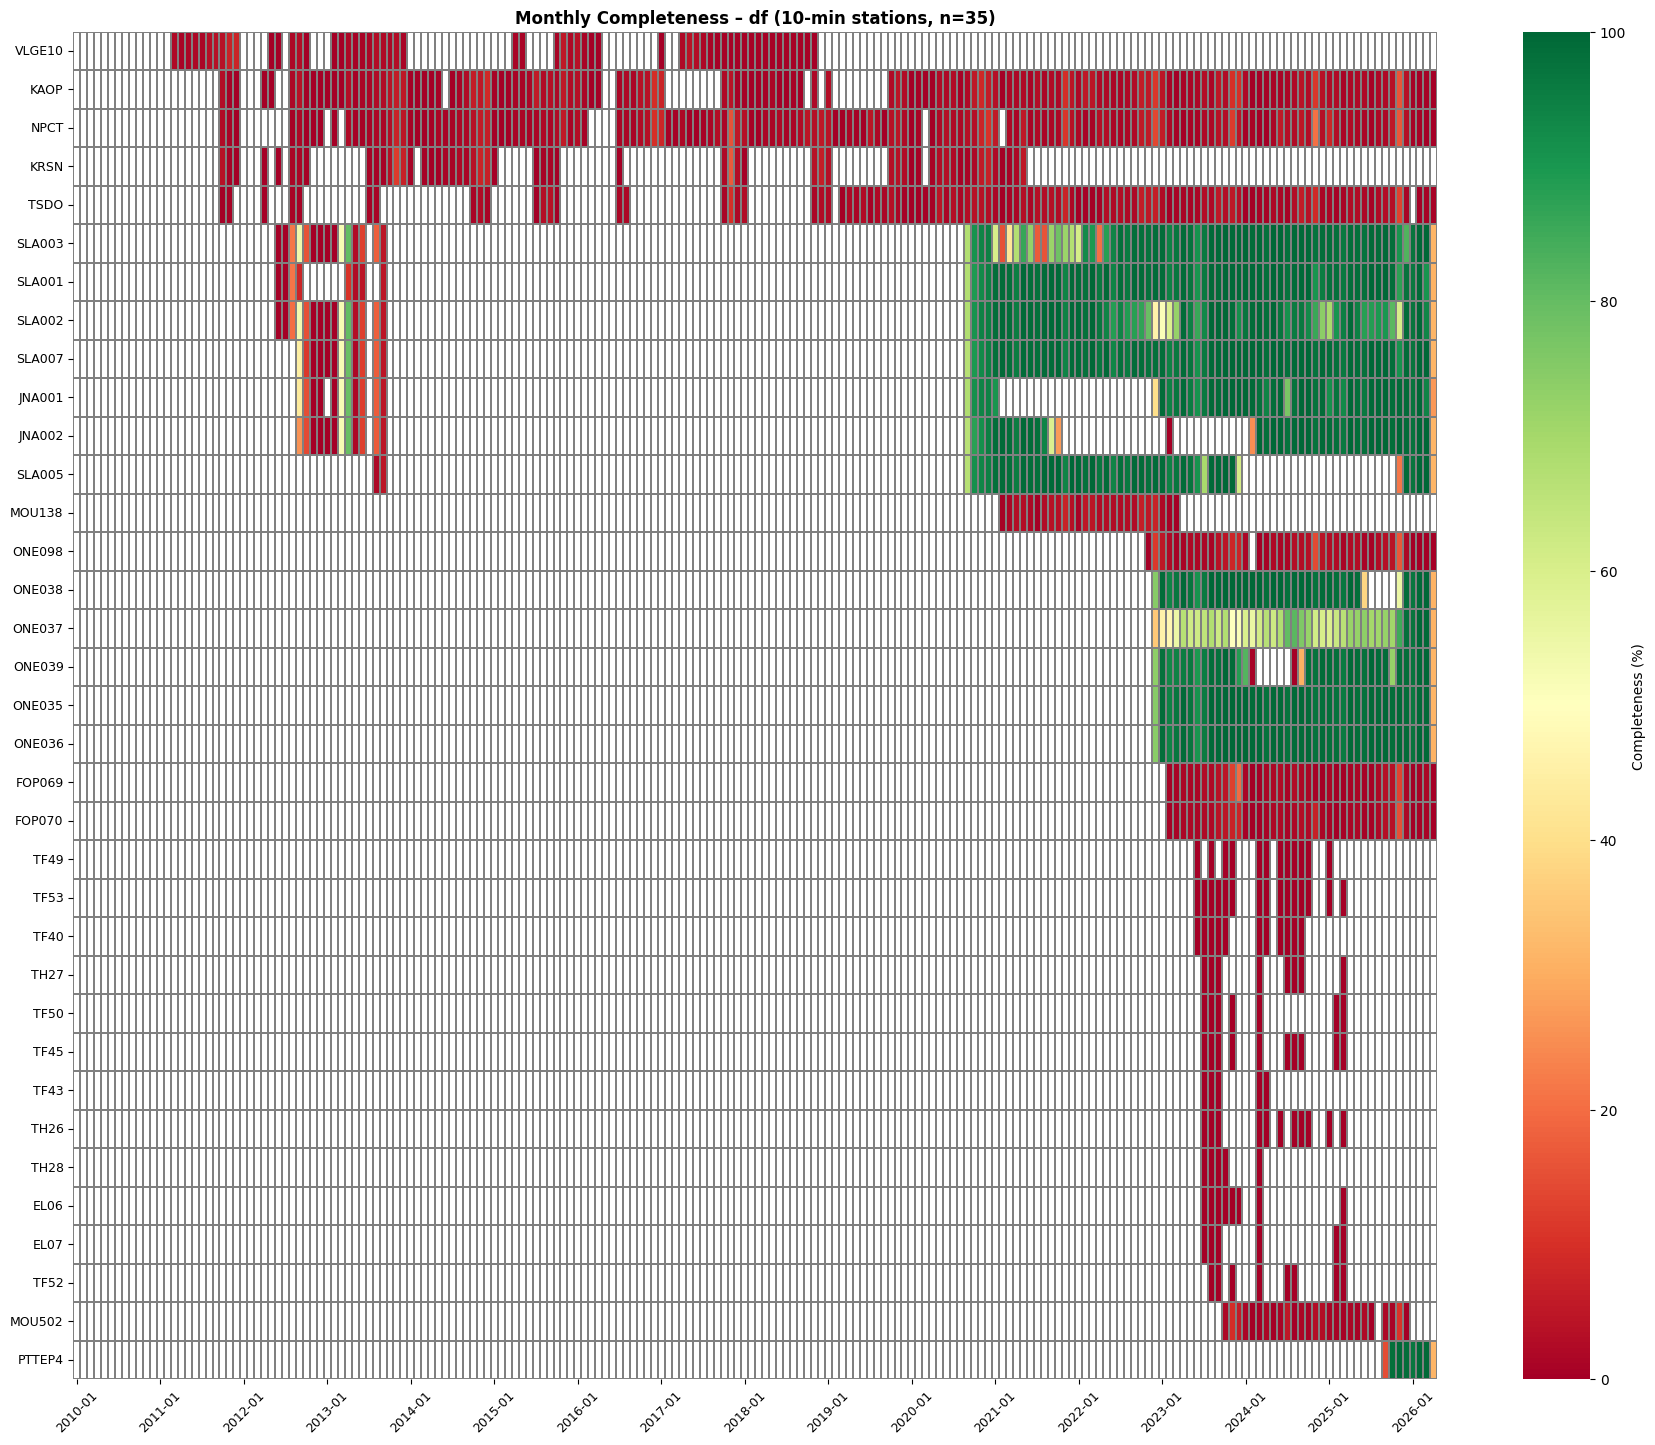

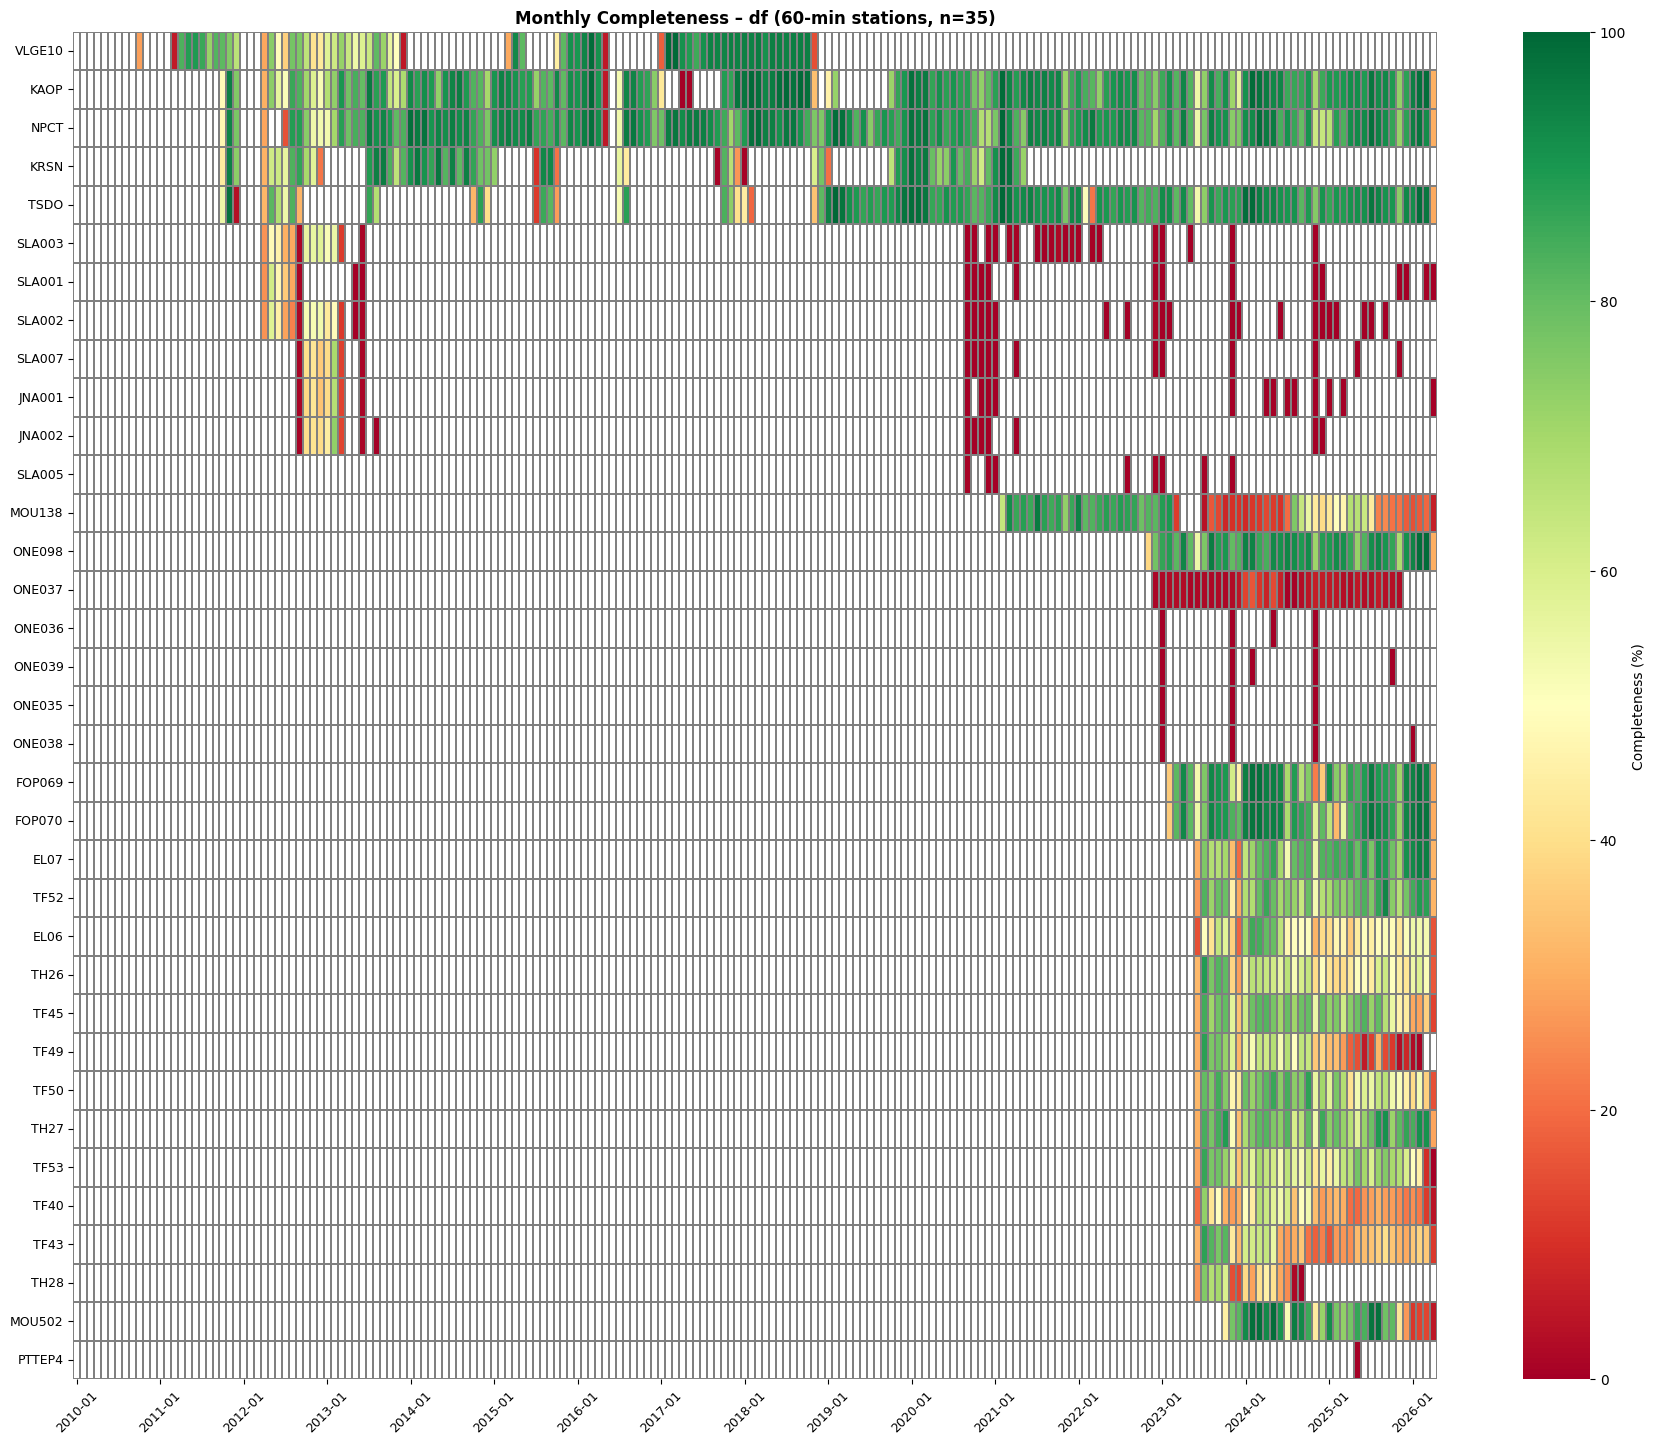

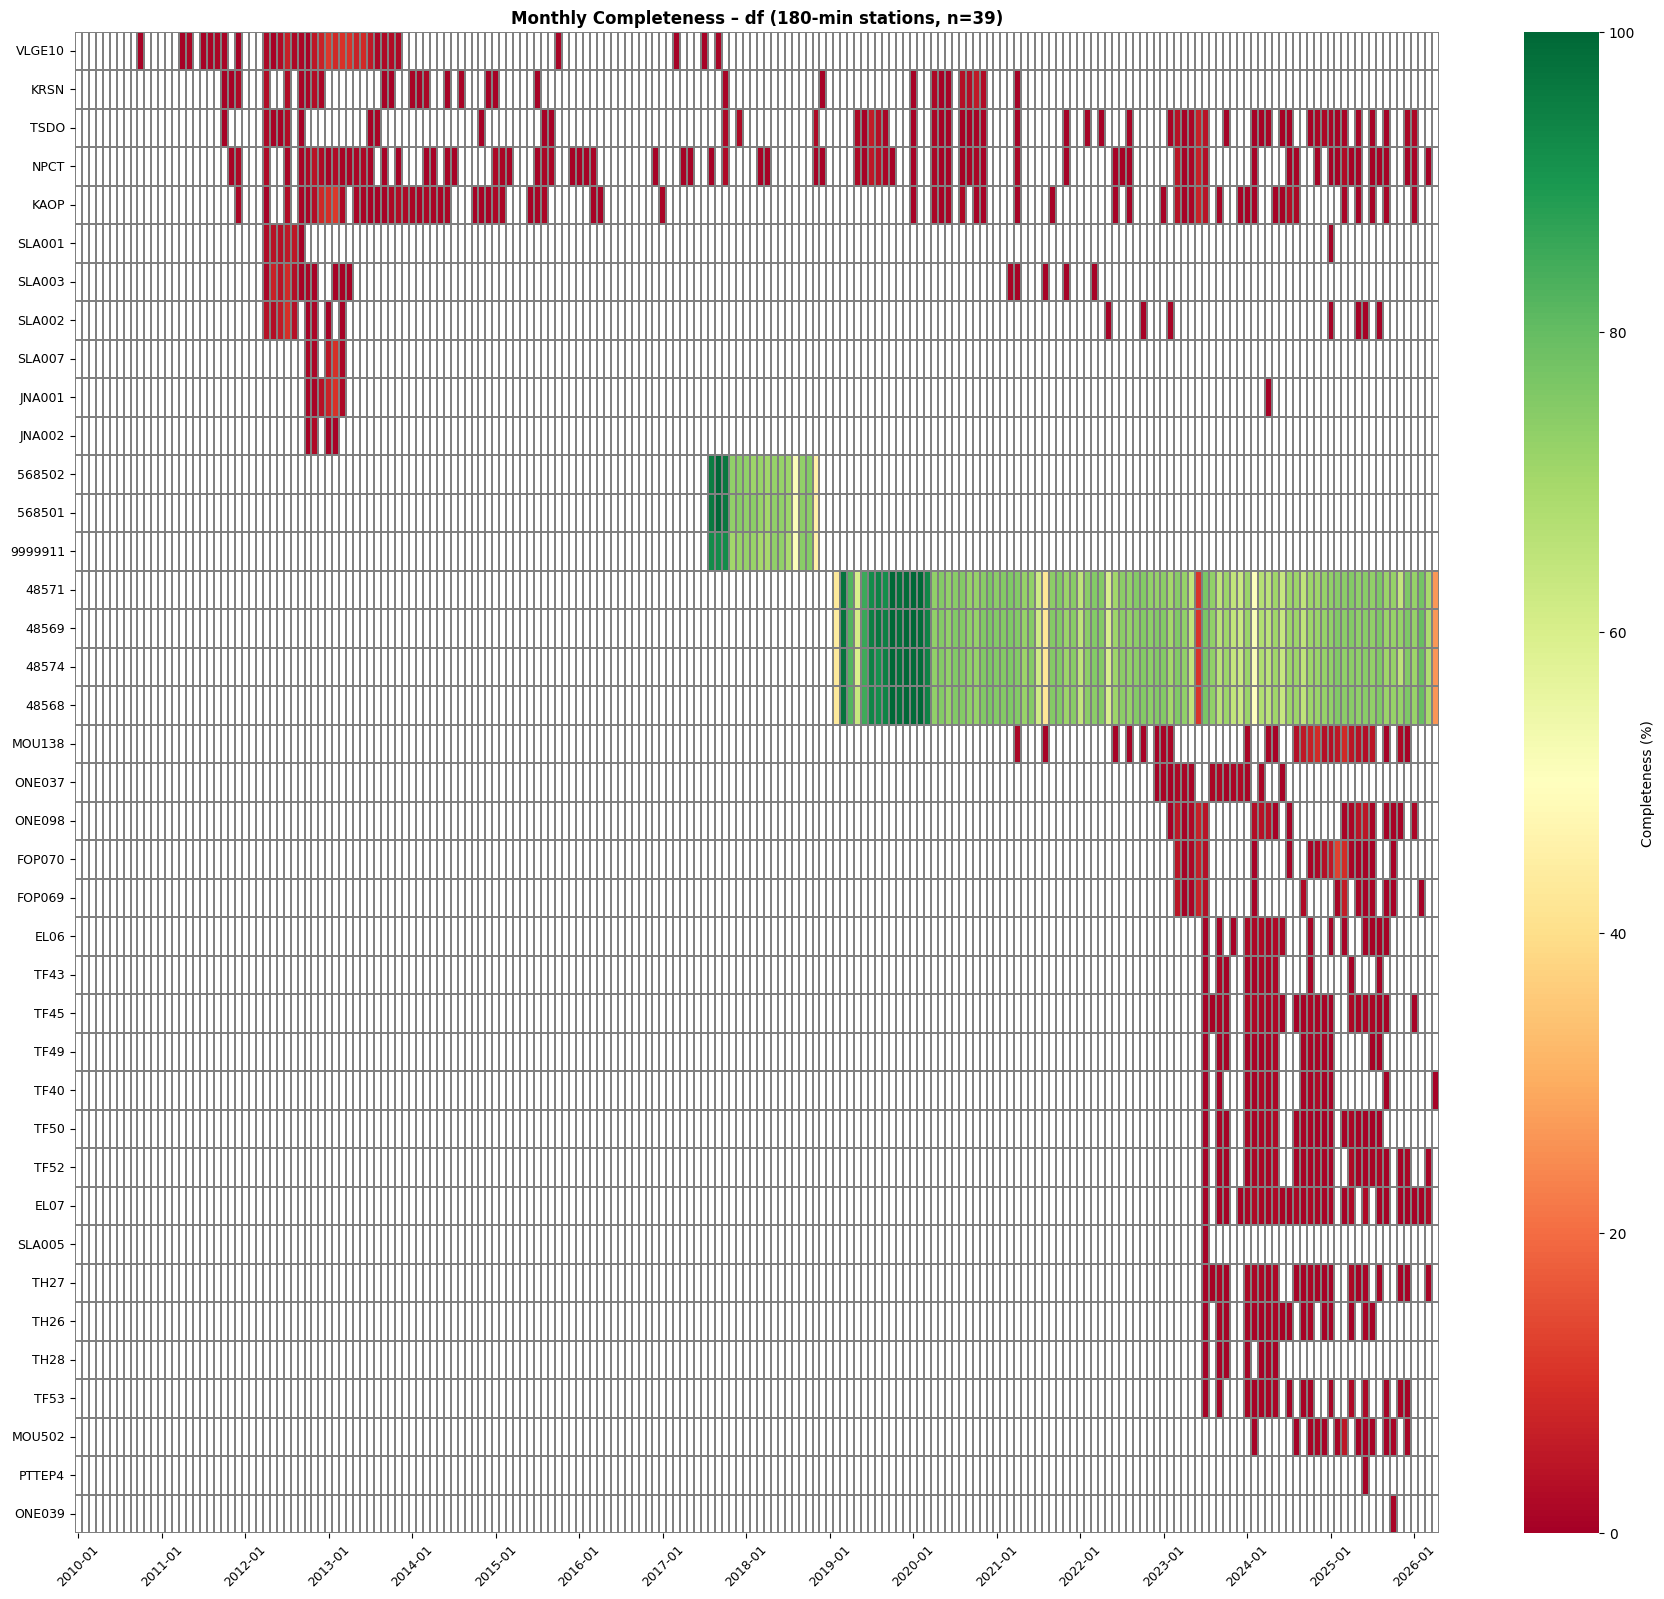

In [35]:
for interval in df_resolution_filtered['interval'].unique():

    df_cadence = df[df['interval'] == interval]
    df_cadence['year_month'] = df_cadence['rainfall_datetime'].dt.to_period('M')
    df_monthly = df_cadence.groupby(['tele_station_oldcode', 'year_month']).size()

    period_index = pd.period_range(
        start=df['rainfall_datetime'].min(),
        end=df['rainfall_datetime'].max(),
        freq='M'
    )

    unique_stn = df_cadence['tele_station_oldcode'].unique()
    full_index = pd.MultiIndex.from_product([unique_stn, period_index], names=['station', 'year_month'])
    df_monthly = df_monthly.reindex(full_index, fill_value=np.nan)

    expected = full_index.get_level_values('year_month').days_in_month * 24 * (60 / interval)
    completeness = (df_monthly / expected) * 100
    unstacked_completeness = completeness.unstack('year_month')

    first_date = unstacked_completeness.apply(lambda x: x.first_valid_index(), axis=1)
    unstacked_completeness = unstacked_completeness.loc[first_date.sort_values().index]

    n_stations = len(unstacked_completeness)
    fig_height = max(6, n_stations * 0.5)
    fig, ax = plt.subplots(figsize=(22, fig_height))
    sns.heatmap(data=unstacked_completeness, ax=ax,
                cmap='RdYlGn', vmin=0, vmax=100,
                linewidths=0.3, linecolor='gray',
                cbar_kws={'label': 'Completeness (%)'},
                xticklabels=12)
    ax.set_title(f'Monthly Completeness – df ({int(interval)}-min stations, n={n_stations})',
                fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='y', labelsize=9)
    ax.tick_params(axis='x', labelsize=9, rotation=45)
    plt.show()